# FS Research Output

Research indicates that injuries often result from a "perfect storm" of factors where baseline vulnerabilities are exacerbated by acute spikes in physical demand. (Think ACWR, can we find a similar measure but just based on match congestion?)

### Biological and Intrinsic Risk Determinants

| Variable Name | Type | Physiological Significance | Data Capture Method |
|---------------|------|----------------------------|--------------------|
| Age | Continuous | Influences tissue elasticity, collagen density, and recovery rates. | Athlete Registration |
| Height/Weight | Continuous | Determines mechanical leverage on joints and total ground reaction forces. | Medical Screening |
| Body Mass Index (BMI) | Derived | Proxy for body composition and mechanical loading efficiency. | Calculated |
| Playing Position | Categorical | Dictates unique movement patterns (e.g., more sprinting for forwards). | Roster Data |
| Injury History | Continuous | Prior injury count is the strongest predictor of future ligament and muscle failures. | Medical Records/Archive |

### Physiological and Recovery Indicators

| Physiological Metric | Sensor Type | Units | Impact on Injury Probability |
|----------------------|-------------|-------|------------------------------|
| Heart Rate Variability (HRV) | PPG / ECG | ms (RMSSD) | Low HRV indicates sympathetic dominance and incomplete recovery. |
| Resting Heart Rate | Chest Strap / PPG | bpm | Elevation above baseline suggests systemic stress or illness. |
| Blood Oxygen (SpO₂) | Pulse Oximetry | % | Reflects cardiorespiratory efficiency and adaptation to altitude or load. |
| Core Body Temperature | Infrared / Pill | °C | Deviations may indicate inflammation or thermal stress. |
| Hydration Level | Bioimpedance | % | Dehydration reduces muscle contractile efficiency and cognitive focus. |

These metrics act as early-warning signals. For instance, a decline in HRV combined with a rise in resting heart rate often precedes "overuse" injuries by 48 to 72 hours, providing the window necessary to modify a player's load before the next match.

### Biomechanical and Kinematic Features

Biomechanical data captures the "how" of movement. It identifies subtle changes in gait, joint angles, or muscle activation that might indicate an impending failure due to fatigue-induced technical breakdown.

| Biomechanical Variable | Metric | Significance |
|------------------------|--------|--------------|
| Electromyography (EMG) | $\mu$V | Measures muscle activation intensity and fatigue-induced drop-off. |
| Joint Angle Symmetry | Degrees | Asymmetry in knee or ankle angles during cutting is a high-risk indicator. |
| Ground Reaction Force | Newtons (N) | High impact forces during landing correlate with ACL and meniscus risk. |
| Gait Speed / Cadence | m/s / spm | Shifts in rhythm often indicate underlying discomfort or fatigue. |
| Range of Motion (ROM) | Degrees | Reductions in flexibility (e.g., hamstring) increase strain during sprints. |

Second-order insights from biomechanical data suggest that "Gait Symmetry" is perhaps more important than absolute speed. A player who maintains speed but shows a 5% shift in weight distribution is often compensating for a sub-clinical tweak, which drastically elevates the risk of a high-grade tear in the subsequent match.

### Workload Dynamics: The Training-Injury Prevention Paradox

$$ACWR = \frac{\text{Sum of Workload over the last 7 days}}{\text{Average weekly workload over the last 28 days}}$$

Evidence suggests that the "sweet spot" for this ratio is 0.8 to 1.3. Within this range, the athlete is being pushed enough to gain fitness but not enough to cause excessive breakdown. When the ratio exceeds 1.5, the risk of injury rises exponentially.

wrt calculating ACWR: While many practitioners use the simple Rolling Average (RA) model, research increasingly supports the use of the Exponentially Weighted Moving Average (EWMA). The EWMA recognizes that a training session performed yesterday has a greater impact on today’s injury risk than a session performed 20 days ago.


## Model Selection

### Deep Learning and Survival Models

the most innovative shift in the field is toward survival analysis models like DeepHit and XGBSE (XGBoost Survival Embeddings).Survival models do not just predict if an injury occurs, but when it is most likely to occur over a continuous time horizon. The DeepHit model, when applied to the SoccerMon dataset of elite footballers, achieved a concordance index of 0.762, proving its ability to accurately order players from highest to lowest risk over time.

### Sliding Window Techniques

The sliding window method converts time-series data into a format suitable for supervised learning. For each day $t$, the model takes a window of data from $t-28$ to $t$ as input and uses the injury status at $t+1$ (the next match) as the target label.

### Time Series Attribution Model

Interesting time series attribution model - https://pmc.ncbi.nlm.nih.gov/articles/PMC10773721/

### Conclusion

To successfully build the requested system, one must integrate these diverse research streams into a unified pipeline. The "Next-Match Prediction" should be conceptualized not as a static classification but as a dynamic survival hazard estimate that is updated after every training session and match.

**The most important variables for this endeavor are the Exponentially Weighted ACWR of high-speed running, Heart Rate Variability (HRV), Sleep Quality, and Gait Symmetry**. These features provide a holistic view of the "Stress-Recovery" balance. The optimal modeling strategy is an ensemble of XGBoost and DeepHit survival models, which allows for both high accuracy on tabular data and the ability to forecast time-varying probabilities.

Finally, the transition from research to deployment hinges on Probability Calibration using Isotonic Regression and the use of SHAP values for interpretability. By sourcing data from the SoccerMon and Multimodal Sports Injury datasets for initial training, and then integrating real-time feeds from Genius Sports or SportsDataIO, practitioners can create a predictive architecture that fundamentally reduces injury incidence while maximizing the competitive availability of their elite athletes.

### Promising Datasets

https://www.kaggle.com/datasets/anjalibhegam/multimodal-sports-injury-dataset
Can do a fairly quick model for soccer players and find important features. Seems to be moment in time data so, best we can do is say when certain features are hightend at a given time you run the risk of injury within the next few days (you've stressed your body too much maybe).

SoccerMon data - Football wellness/health stats over a 2 year period for elite woman's football in Norweigian league
https://github.com/simula/soccermon - Package for reading the SoccerMon data
See this paper on time-to-injury forecast using SoccerMon dataset (replicate this)
    - Goal of model in paper “Given an athlete’s data from the past 21 days, what is the probability that they will sustain an injury within the next 7 days?”



## Other Notes

Tracking data feature engineering paper - https://pmc.ncbi.nlm.nih.gov/articles/PMC10893073/

Model agnostic feature selection technique - mRMR is a model-agnostic feature selection mechanism that finds an optimal set of features that minimizes the redundancy between the independent variables

Features often standing out that leads to injury: **high stress, high high-intensity running volume, low mood, and low sleep quality**


## Modelling Approach

Quick point-in-time model built on kaggle dataset (soccer players) and identify important features

Replicate Deephit model in paper that uses SoccerMon data (https://arxiv.org/html/2601.19479v1) and visualise it like this:
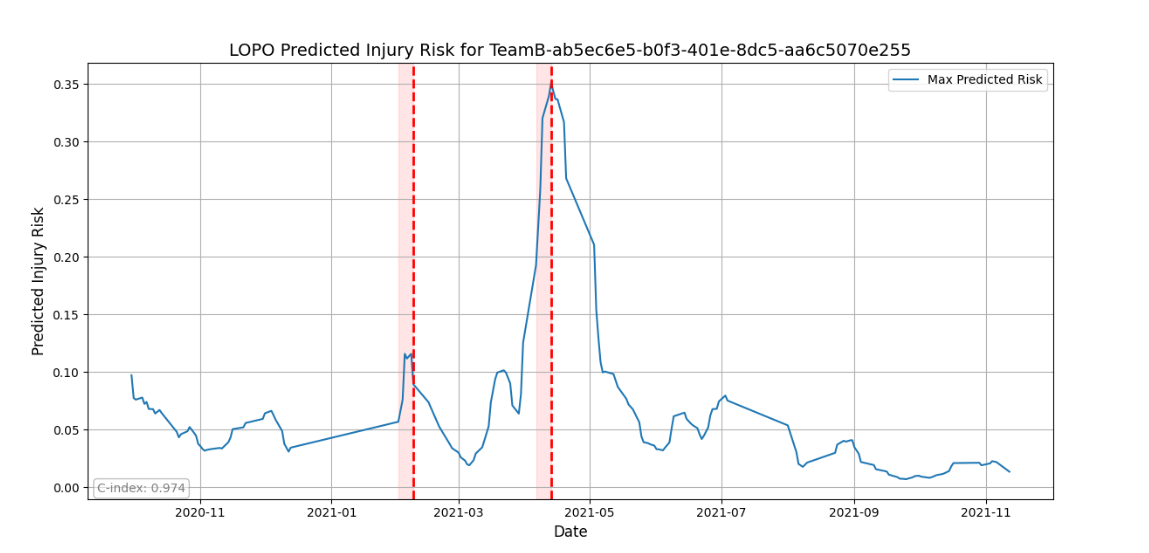 